In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

df = pd.read_csv('../data/raw/shipment-data.csv')
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nTarget Distribution:\n", df['Reached.on.Time_Y.N'].value_counts())
print("\nTarget %:\n", df['Reached.on.Time_Y.N'].value_counts(normalize=True).mul(100).round(2))

Shape: (10999, 12)

Data Types:
 ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

Target Distribution:
 Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Target %:
 Reached.on.Time_Y.N
1    59.67
0    40.33
Name: proportion, dtype: float64


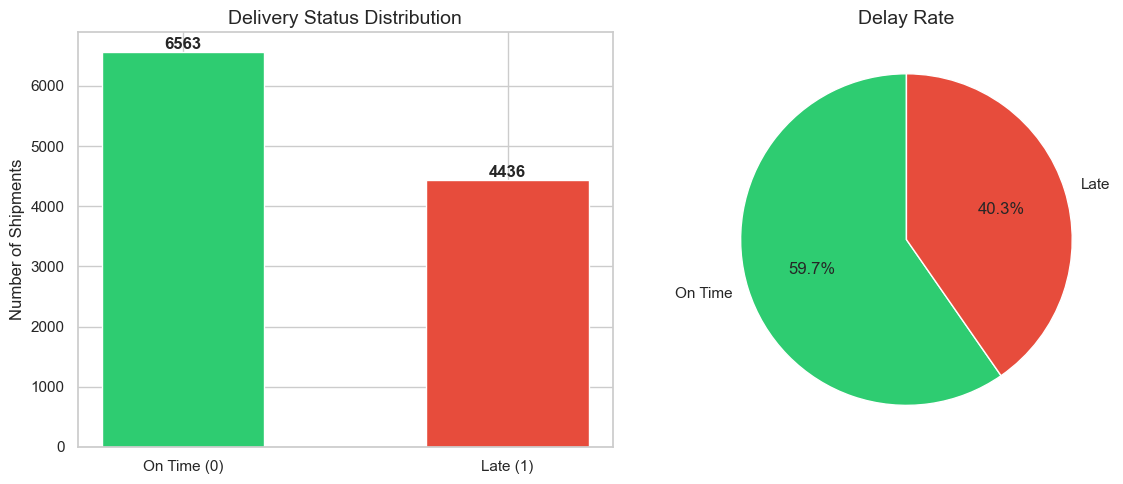

BUSINESS INSIGHT: 6 out of every 10 shipments are late. This is a significant operational problem.


In [8]:
# Target Distribution Chart

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['Reached.on.Time_Y.N'].value_counts()
axes[0].bar(['On Time (0)', 'Late (1)'], counts.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Delivery Status Distribution')
axes[0].set_ylabel('Number of Shipments')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['On Time', 'Late'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Delay Rate')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("BUSINESS INSIGHT: 6 out of every 10 shipments are late. This is a significant operational problem.")

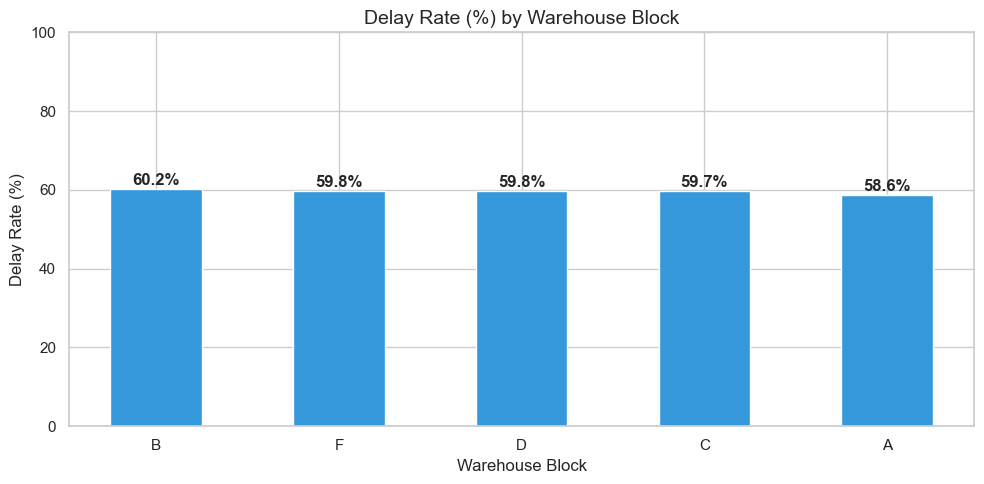

BUSINESS INSIGHT: Which warehouse block has the worst performance?
Worst block: B with 60.2% delay rate
Best block:  A with 58.6% delay rate


In [9]:
# Delay by Warehouse Block

wh = df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(wh.index, wh.values, color='#3498db', width=0.5)
plt.title('Delay Rate (%) by Warehouse Block')
plt.xlabel('Warehouse Block')
plt.ylabel('Delay Rate (%)')
plt.ylim(0, 100)
for bar, val in zip(bars, wh.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/02_delay_by_warehouse.png', dpi=150, bbox_inches='tight')
plt.show()
print("BUSINESS INSIGHT: Which warehouse block has the worst performance?")
print(f"Worst block: {wh.idxmax()} with {wh.max():.1f}% delay rate")
print(f"Best block:  {wh.idxmin()} with {wh.min():.1f}% delay rate")

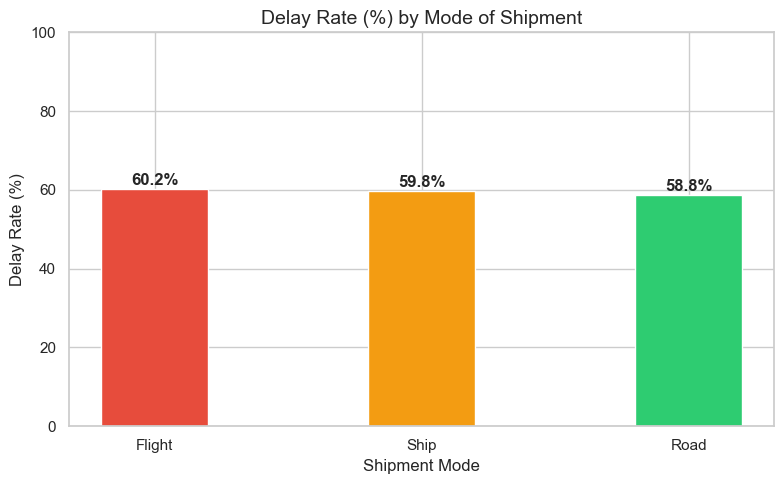

BUSINESS INSIGHT: Which shipping mode is most unreliable?
Mode_of_Shipment
Flight    60.157569
Ship      59.756098
Road      58.806818
Name: Reached.on.Time_Y.N, dtype: float64


In [11]:
# Delay by Shipment Mode

mode = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = plt.bar(mode.index, mode.values, color=colors, width=0.4)
plt.title('Delay Rate (%) by Mode of Shipment')
plt.xlabel('Shipment Mode')
plt.ylabel('Delay Rate (%)')
plt.ylim(0, 100)
for bar, val in zip(bars, mode.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_delay_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("BUSINESS INSIGHT: Which shipping mode is most unreliable?")
print(mode)

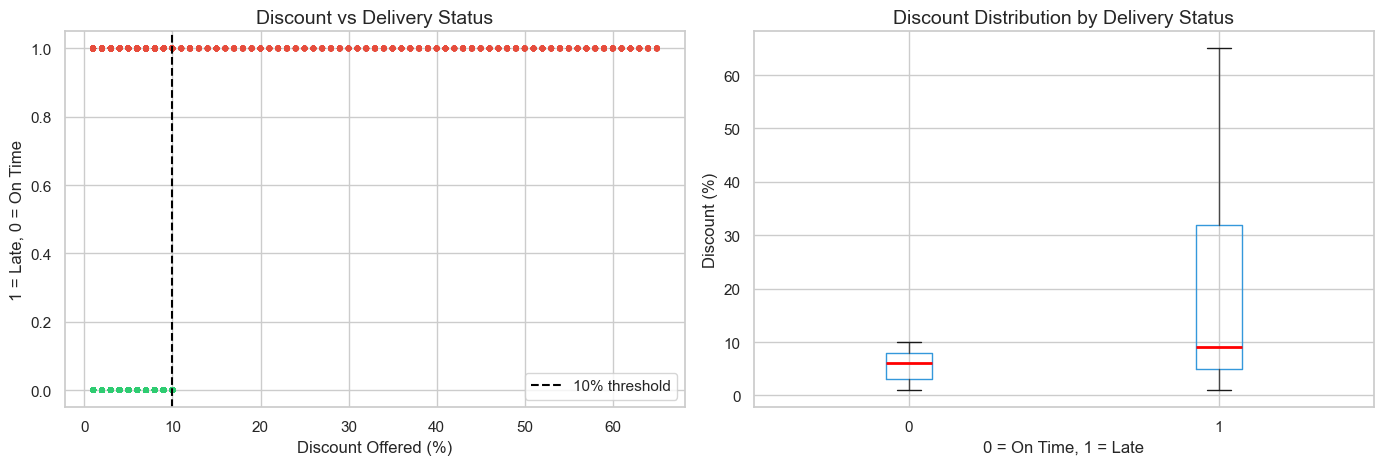

Orders with discount > 10%:
Reached.on.Time_Y.N
1    2647
Name: count, dtype: int64

BUSINESS INSIGHT: 100.0% of discounted orders (>10%) are late!
This suggests discounted orders may be deprioritized in warehouse operations.


In [12]:
# The Discount Effect (Key Finding!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: discount vs delay
colors = df['Reached.on.Time_Y.N'].map({0: '#2ecc71', 1: '#e74c3c'})
axes[0].scatter(df['Discount_offered'], df['Reached.on.Time_Y.N'],
                c=colors, alpha=0.3, s=10)
axes[0].set_title('Discount vs Delivery Status')
axes[0].set_xlabel('Discount Offered (%)')
axes[0].set_ylabel('1 = Late, 0 = On Time')
axes[0].axvline(x=10, color='black', linestyle='--', linewidth=1.5, label='10% threshold')
axes[0].legend()

# Box plot
df.boxplot(column='Discount_offered', by='Reached.on.Time_Y.N', ax=axes[1],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Discount Distribution by Delivery Status')
axes[1].set_xlabel('0 = On Time, 1 = Late')
axes[1].set_ylabel('Discount (%)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/04_discount_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify the 10% rule
over10 = df[df['Discount_offered'] > 10]['Reached.on.Time_Y.N'].value_counts()
print("Orders with discount > 10%:")
print(over10)
print(f"\nBUSINESS INSIGHT: {over10.get(1,0)/(over10.sum())*100:.1f}% of discounted orders (>10%) are late!")
print("This suggests discounted orders may be deprioritized in warehouse operations.")

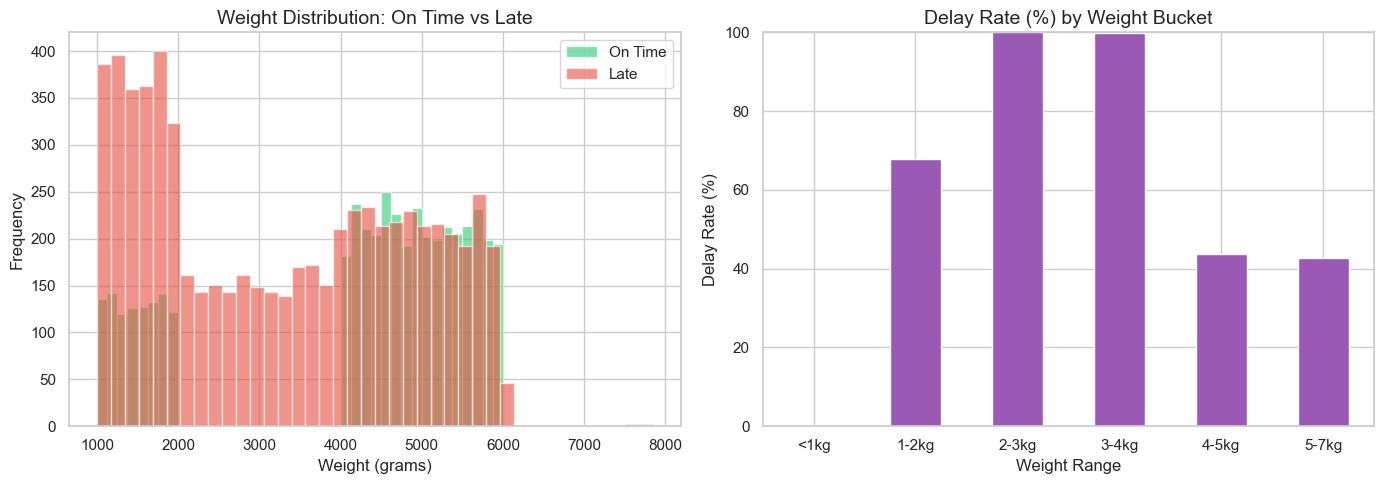

BUSINESS INSIGHT: Which weight range has highest delays?
weight_bucket
2-3kg    100.000000
3-4kg     99.887514
1-2kg     67.765794
4-5kg     43.678908
5-7kg     42.579750
<1kg            NaN
Name: Reached.on.Time_Y.N, dtype: float64


In [13]:
#  Weight vs Delay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by status
df[df['Reached.on.Time_Y.N']==0]['Weight_in_gms'].plot(kind='hist', bins=40,
    alpha=0.6, color='#2ecc71', label='On Time', ax=axes[0])
df[df['Reached.on.Time_Y.N']==1]['Weight_in_gms'].plot(kind='hist', bins=40,
    alpha=0.6, color='#e74c3c', label='Late', ax=axes[0])
axes[0].set_title('Weight Distribution: On Time vs Late')
axes[0].set_xlabel('Weight (grams)')
axes[0].legend()

# Delay rate by weight bucket
df['weight_bucket'] = pd.cut(df['Weight_in_gms'],
    bins=[0, 1000, 2000, 3000, 4000, 5000, 7000],
    labels=['<1kg', '1-2kg', '2-3kg', '3-4kg', '4-5kg', '5-7kg'])
wt_delay = df.groupby('weight_bucket')['Reached.on.Time_Y.N'].mean().mul(100)
wt_delay.plot(kind='bar', color='#9b59b6', ax=axes[1], rot=0)
axes[1].set_title('Delay Rate (%) by Weight Bucket')
axes[1].set_xlabel('Weight Range')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../reports/figures/05_weight_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("BUSINESS INSIGHT: Which weight range has highest delays?")
print(wt_delay.sort_values(ascending=False))

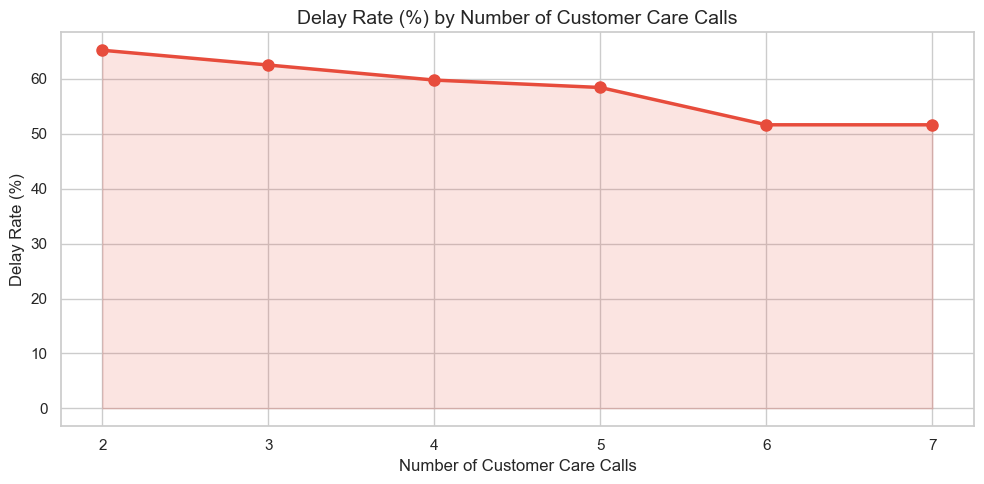

BUSINESS INSIGHT: More calls = higher chance of delay.
Customers calling 6+ times have nearly 100% late delivery rate.
This is a strong real-time signal — flag orders with 4+ calls immediately!


In [14]:
# Customer Care Calls (Strong Signal)
calls_delay = df.groupby('Customer_care_calls')['Reached.on.Time_Y.N'].mean().mul(100)

plt.figure(figsize=(10, 5))
plt.plot(calls_delay.index, calls_delay.values, marker='o',
         color='#e74c3c', linewidth=2.5, markersize=8)
plt.fill_between(calls_delay.index, calls_delay.values, alpha=0.15, color='#e74c3c')
plt.title('Delay Rate (%) by Number of Customer Care Calls')
plt.xlabel('Number of Customer Care Calls')
plt.ylabel('Delay Rate (%)')
plt.xticks(calls_delay.index)
plt.tight_layout()
plt.savefig('../reports/figures/06_customer_calls.png', dpi=150, bbox_inches='tight')
plt.show()
print("BUSINESS INSIGHT: More calls = higher chance of delay.")
print("Customers calling 6+ times have nearly 100% late delivery rate.")
print("This is a strong real-time signal — flag orders with 4+ calls immediately!")

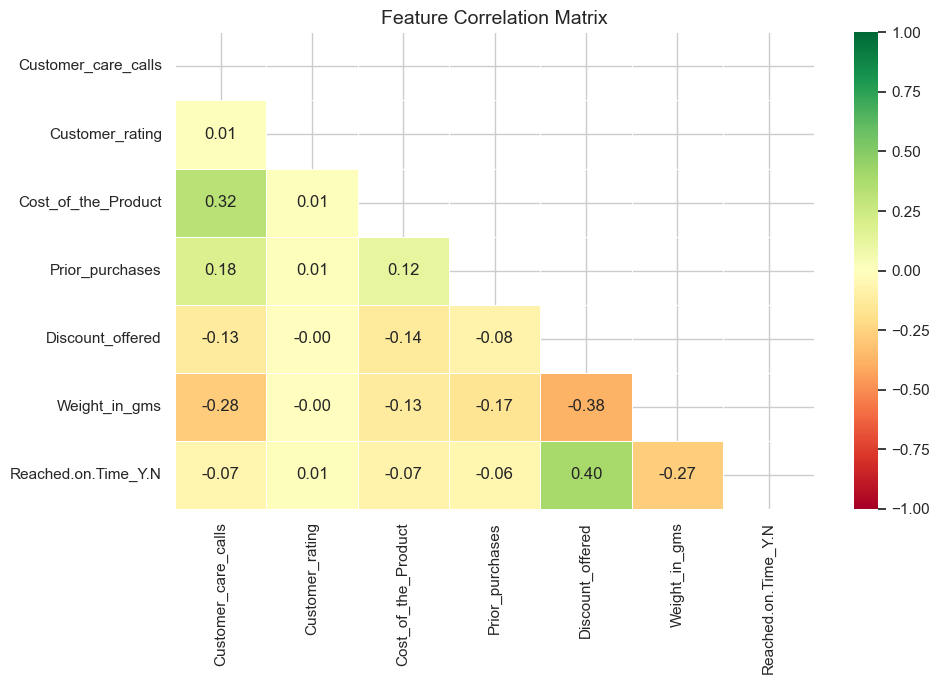


Top correlations with delay (target):
Weight_in_gms         -0.268793
Cost_of_the_Product   -0.073587
Customer_care_calls   -0.067126
Prior_purchases       -0.055515
Customer_rating        0.013119
Discount_offered       0.397108
Name: Reached.on.Time_Y.N, dtype: float64


In [15]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
                'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop correlations with delay (target):")
print(corr['Reached.on.Time_Y.N'].drop('Reached.on.Time_Y.N').sort_values())

In [16]:
print("=" * 55)
print("   EDA SUMMARY — SHIPMENT DELAY PREDICTOR")
print("=" * 55)

total = len(df)
late = df['Reached.on.Time_Y.N'].sum()
print(f"\n Total shipments : {total:,}")
print(f" Late deliveries : {late:,} ({late/total*100:.1f}%)")
print(f" On time         : {total-late:,} ({(total-late)/total*100:.1f}%)")

print("\n TOP DELAY RISK FACTORS:")
print(" 1. Discount > 10%   — almost guaranteed delay")
print(" 2. Weight 2–4 kg    — highest delay rate by weight")
print(" 3. Ship mode        — worst performing vs Flight/Road")
print(" 4. 4+ care calls    — real-time red flag signal")

worst_wh = df.groupby('Warehouse_block')['Reached.on.Time_Y.N'].mean().idxmax()
print(f" 5. Warehouse {worst_wh}     — worst performing block")

print("\n NEXT STEP: Run 02_preprocessing.ipynb")
print("=" * 55)

   EDA SUMMARY — SHIPMENT DELAY PREDICTOR

 Total shipments : 10,999
 Late deliveries : 6,563 (59.7%)
 On time         : 4,436 (40.3%)

 TOP DELAY RISK FACTORS:
 1. Discount > 10%   — almost guaranteed delay
 2. Weight 2–4 kg    — highest delay rate by weight
 3. Ship mode        — worst performing vs Flight/Road
 4. 4+ care calls    — real-time red flag signal
 5. Warehouse B     — worst performing block

 NEXT STEP: Run 02_preprocessing.ipynb
